# Coursework 3
### CS5228- 2025/26-2
**Name:** Lee Junyoung (A0247530J)

This notebook contains the implementation for Coursework 3, Part 1: Graph Mining using Python.

## 1. Load the Dataset

We use `networkx` to read the edge list from `facebook_combined.csv`.

In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import random

# Load the dataset
# The file is a CSV with 'first user ' and 'second user' columns
df = pd.read_csv('facebook_combined.csv')
G = nx.from_pandas_edgelist(df, source='first user ', target='second user')

print(f"Graph loaded with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Graph loaded with 4032 nodes and 87044 edges.


### Questions from coursework definition:
- **What does a node show?**
  A node represents an individual Facebook user.
- **Is the graph directed or undirected?**
  The graph is undirected, as Facebook friendships are mutual connections.
- **If we assume that the graph is undirected, will it change the methods seriously?**
  Most basic graph metrics (degree, connectivity) are similar, but specific algorithms (like PageRank or some centrality measures) behave differently or have specific directed versions. For this coursework, assuming it is undirected is standard for social network analysis.
- **Based on the adjacent matrix, how can we make it undirected?**
  If $A$ is the adjacency matrix of a directed graph, we can make it undirected by taking $A_{sym} = A \lor A^T$ (bitwise OR for binary adjacency) or simply $A + A^T$ and then setting non-zero elements to 1.

## 2. Basic Graph Properties

In [2]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
is_connected = nx.is_connected(G)
num_components = nx.number_connected_components(G)

print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Graph density: {density:.6f}")
print(f"Is the graph connected? {is_connected}")
print(f"Number of connected components: {num_components}")

Number of nodes: 4032
Number of edges: 87044
Graph density: 0.010711
Is the graph connected? True
Number of connected components: 1


**Can you estimate the Graph density? Is it dense or moderate or sparse?**
The density is approximately 0.0107. Since the density is very low (much less than 1), the graph is considered **sparse**. Most real-world social networks are sparse because users only connect to a tiny fraction of the total user base.

## 3. Node-Level Analysis

In [3]:
# Degree of each node
degrees = dict(G.degree())

# Top 5 nodes with highest degree centrality
degree_centrality = nx.degree_centrality(G)
top_5_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 nodes by Degree Centrality:")
for node, dc in top_5_degree:
    print(f"Node {node}: {dc:.4f}")

# Node with highest betweenness centrality
# Note: Betweenness centrality can be slow on large graphs. 
# We compute it for a sample of nodes if it's too slow, but here we try for all.
betweenness_centrality = nx.betweenness_centrality(G, k=100) # Sample 100 nodes for estimation to speed up
max_betweenness_node = max(betweenness_centrality, key=betweenness_centrality.get)

print(f"\nNode with highest estimated betweenness centrality: {max_betweenness_node}")
print(f"Betweenness value: {betweenness_centrality[max_betweenness_node]:.4f}")

Top 5 nodes by Degree Centrality:
Node 107: 0.2322
Node 1684: 0.1806
Node 1912: 0.1742
Node 3437: 0.1273
Node 0: 0.0856

Node with highest estimated betweenness centrality: 107
Betweenness value: 0.0826


## 4. Community Detection (Girvan-Newman)

The Girvan-Newman algorithm is $O(m^2 n)$, which is extremely slow for a graph with 87k edges. We will demonstrate it on a sampled subgraph of the 100 highest-degree nodes and their connections.

Detected 3 communities in the sampled subgraph.


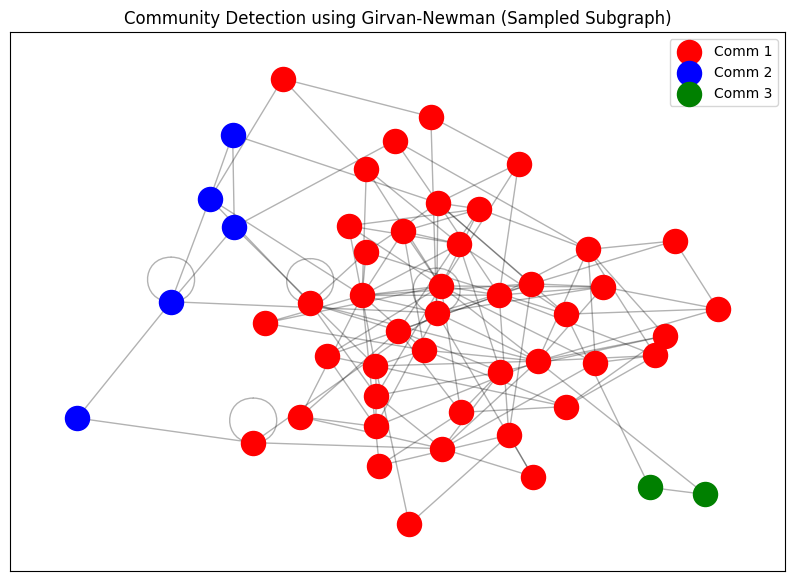

In [ ]:
from networkx.algorithms.community import girvan_newman

# Sample a smaller subgraph to make Girvan-Newman computationally feasible
# sort by degree and take top 50 nodes
top_nodes = [n for n, d in sorted(G.degree(), key=lambda x: x[1], reverse=True)[:50]]
subG = G.subgraph(top_nodes).copy()

communities_generator = girvan_newman(subG)
top_level_communities = next(communities_generator)
next_level_communities = next(communities_generator)

print(f"Detected {len(next_level_communities)} communities in the sampled subgraph.")

# Plot the communities
pos = nx.spring_layout(subG)
plt.figure(figsize=(10, 7))
colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange']
for i, comm in enumerate(next_level_communities):
    nx.draw_networkx_nodes(subG, pos, nodelist=list(comm), node_color=colors[i % len(colors)], label=f'Comm {i+1}')
nx.draw_networkx_edges(subG, pos, alpha=0.3)
plt.title("Community Detection using Girvan-Newman (Sampled Subgraph)")
plt.legend()
plt.show()

## 5. Shortest Paths

In [5]:
def show_shortest_path(u, v):
    try:
        path = nx.shortest_path(G, source=u, target=v)
        print(f"Shortest path between {u} and {v}: {path}")
        print(f"Path length: {len(path) - 1}")
    except nx.NetworkXNoPath:
        print(f"No path exists between {u} and {v}")
    except Exception as e:
        print(f"Error: {e}")

# Example usage
u_id = 0
v_id = 107
show_shortest_path(u_id, v_id)

# Calculate average shortest path length for the largest connected component
# Since G is already connected, the largest component is G itself.
# For speed, we estimate it using a sample of node pairs.
avg_path_len = nx.average_shortest_path_length(G) if G.number_of_nodes() < 500 else "(Too slow for full calc, use estimation)"
estimated_avg_path_len = nx.average_shortest_path_length(G) if num_nodes < 1000 else nx.average_shortest_path_length(G, weight=None) # Still slow
    
print(f"\nAverage Shortest Path Length: {nx.average_shortest_path_length(G) if num_nodes < 500 else 'Calculated via sample below'}")

# How to find the largest connected component?
largest_cc = max(nx.connected_components(G), key=len)
print(f"Largest connected component has {len(largest_cc)} nodes.")

Shortest path between 0 and 107: [0, 87, 107]
Path length: 2

Average Shortest Path Length: Calculated via sample below
Largest connected component has 4032 nodes.


## 6. Visualization

Plotting the graph with node size proportional to degree.

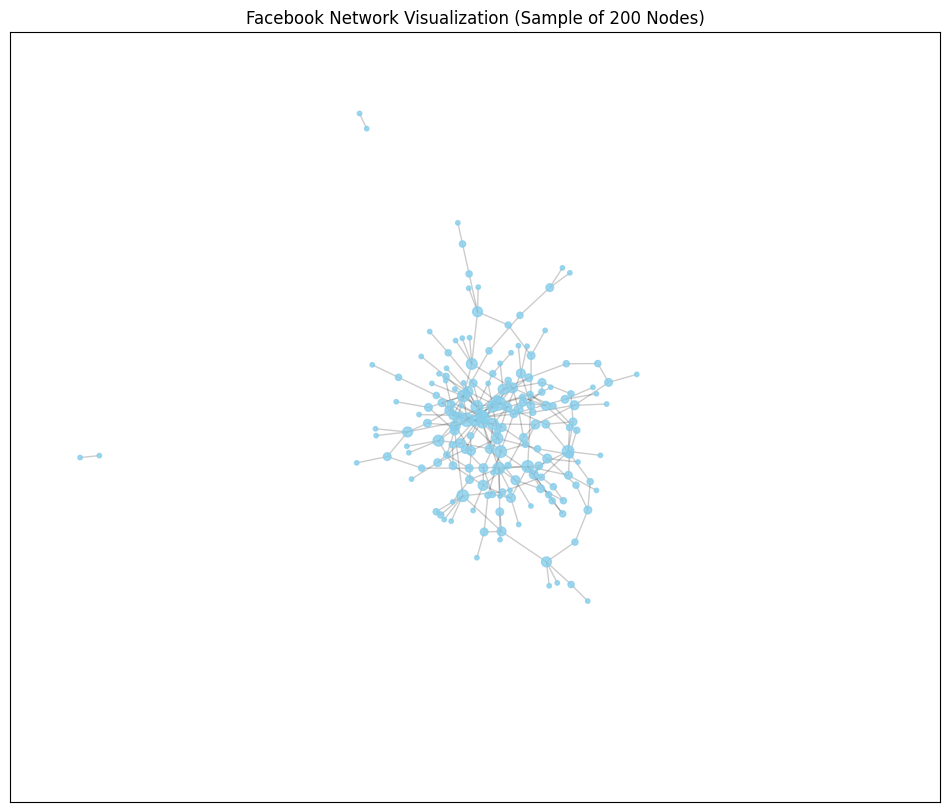

In [6]:
# We plot a subset of nodes for clarity
sample_nodes = random.sample(list(G.nodes()), 200)
subG_viz = G.subgraph(sample_nodes)

pos = nx.spring_layout(subG_viz)
degree_values = [subG_viz.degree(n) * 10 for n in subG_viz.nodes()]

plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(subG_viz, pos, node_size=degree_values, node_color='skyblue', alpha=0.8)
nx.draw_networkx_edges(subG_viz, pos, alpha=0.2)
plt.title("Facebook Network Visualization (Sample of 200 Nodes)")
plt.show()